# TI-Toolbox scripting walkthrough

An end-to-end example of the `tit` Python API, run against the public **Dataset 000** (`sub-ernie`)
inside the TI-Toolbox container. Every cell below was executed for real; the outputs are the
outputs you should expect on your own machine.

What it covers:

1. Locating a project and its subjects with `PathManager`
2. Loading a montage from `montage_list.json` and defining one by hand
3. Running a TI simulation with `SimulationConfig` / `run_simulation`
4. Finding the outputs on disk
5. Analysing the field in a spherical ROI (voxel space) and an atlas region (mesh space)
6. Plotting the result inline with nilearn / matplotlib
7. A batch loop over subjects

**How to run it yourself:** start the toolbox, open a shell in the container
(`docker exec -it simnibs_container bash`), run `NOTEBOOK`, open <http://localhost:8888>,
upload this file and pick the *SimNIBS + TI-Toolbox* kernel. Change `PROJECT` and `SUBJECT`
to match your data. The simulation cell takes a few minutes on a single core.

## 1. Project and subjects

In [1]:
from tit import get_path_manager

PROJECT = "/mnt/000"     # your BIDS project root, as mounted in the container
SUBJECT = "ernie"

pm = get_path_manager(PROJECT)
print("project_dir :", pm.project_dir)
print("subjects    :", pm.list_simnibs_subjects())     # subjects that already have an m2m_* head model
print("m2m         :", pm.m2m(SUBJECT))
print("simulations :", pm.list_simulations(SUBJECT))

project_dir : /mnt/000
subjects    : ['101', 'ernie', 'MNI152']
m2m         : /mnt/000/derivatives/SimNIBS/sub-ernie/m2m_ernie
simulations : ['L_Insula', 'Thalamus', 'docs_example', 'flex_20260709_011433_33abc141_mapped', 'flex_20260709_021442_285db057_mapped', 'notebook_example']


## 2. Montages

Montages live in `<project>/code/ti-toolbox/config/montage_list.json`, keyed by EEG net.
`load_montages()` reads them; you can also build a `Montage` directly.

In [2]:
from tit.sim import Montage, load_montages

EEG_NET = "GSN-HydroCel-185.csv"

# A: from montage_list.json
saved = load_montages(montage_names=["L_Insula"], eeg_net=EEG_NET)
for m in saved:
    print(m.name, m.simulation_mode, m.electrode_pairs)

# B: defined inline (same electrode pairs, new name so we don't overwrite anything)
montage = Montage(
    name="notebook_example",
    mode=Montage.Mode.NET,
    electrode_pairs=[("E034", "E020"), ("E095", "E070")],
    eeg_net=EEG_NET,
)
print(montage.name, montage.simulation_mode, montage.electrode_pairs)

L_Insula SimulationMode.TI [['E034', 'E020'], ['E095', 'E070']]
notebook_example SimulationMode.TI [('E034', 'E020'), ('E095', 'E070')]


## 3. Run a TI simulation

`SimulationConfig` holds everything the GUI's Simulator tab asks for. Two electrode pairs
→ standard TI; four or more → mTI, detected automatically. `map_to_mni=True` also writes
MNI-space NIfTIs so we can overlay the result on a template later.

In [3]:
import time
from tit.sim import SimulationConfig, run_simulation

config = SimulationConfig(
    subject_id=SUBJECT,
    montages=[montage],
    conductivity="scalar",              # "scalar" | "vn" | "dir" | "mc"
    intensities=[1.0, 1.0],             # mA per pair
    electrode_shape="ellipse",
    electrode_dimensions=[8.0, 8.0],    # mm
    gel_thickness=4.0,
    rubber_thickness=2.0,
    output_fields=["TI_max"],           # add "TI_avg", "hf_peak", "hf_sar" if needed
    map_to_mni=True,
    map_to_fsavg=False,
)

def progress(i, n, name):
    print(f"[{i}/{n}] {name}", flush=True)

t0 = time.time()
results = run_simulation(config, progress_callback=progress)
print(f"finished in {time.time() - t0:.0f} s")
results

[1/1] TI: notebook_example


[0/1] notebook_example


Config written: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/documentation/config.json


SimNIBS simulation: Started


[ simnibs ] INFO: Head Mesh:          /mnt/000/derivatives/SimNIBS/sub-ernie/m2m_ernie/ernie.msh


...

NIfTI transformation: ✓ Complete


✓ notebook_example complete


[1/1] Complete


finished in 502 s


[{'montage_name': 'notebook_example',
  'montage_type': 'TI',
  'status': 'completed',
  'output_mesh': '/mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/TI/mesh/notebook_example_TI.msh'}]

## 4. What was written

In [4]:
import os
from pathlib import Path

sim_dir = Path(pm.simulation(SUBJECT, montage.name))
print(sim_dir)
for root, dirs, files in os.walk(sim_dir):
    depth = len(Path(root).relative_to(sim_dir).parts)
    print("    " * depth + Path(root).name + "/")
    for f in sorted(files):
        print("    " * (depth + 1) + f)

/mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example


notebook_example/
    documentation/
        config.json
        simnibs_simulation_20260826-223742.log
        simnibs_simulation_20260826-223742.mat
        simnibs_simulation_20260826-224747.log
        simnibs_simulation_20260826-224747.mat
    high_Frequency/
        .lg.png
        mesh/
            ernie_TDCS_1_el_currents.geo
            ernie_TDCS_1_scalar.msh
            ernie_TDCS_1_scalar.msh.opt
            ernie_TDCS_2_el_currents.geo
            ernie_TDCS_2_scalar.msh
            ernie_TDCS_2_scalar.msh.opt
        analysis/
            fields_summary.txt
        niftis/
            ernie_TDCS_1_scalar_MNI_MNI_magnE.nii.gz
            ernie_TDCS_1_scalar_subject_magnE.nii.gz
            ernie_TDCS_2_scalar_MNI_MNI_magnE.nii.gz
            ernie_TDCS_2_scalar_subject_magnE.nii.gz
    Analyses/
        Mesh/
            cortical_lh.precentral_DK40/
                results.csv
            cortical_lh.superiorfrontal_DK40/
                results.csv
            cortical_rh

## 5. Analyse the field

`Analyzer` wraps the Analyzer tab. Point it at a finished simulation, choose `space="voxel"`
(NIfTI) or `space="mesh"` (GM surface), then call `analyze_sphere()` or `analyze_cortex()`.
`visualize=True` additionally writes overlays, histograms and CSVs next to the simulation.

In [5]:
from dataclasses import asdict
import pandas as pd
from tit.analyzer import Analyzer

voxel = Analyzer(subject_id=SUBJECT, simulation=montage.name, space="voxel")
sphere = voxel.analyze_sphere(
    center=(-35.0, 5.0, 5.0),   # left insula, MNI
    radius=10.0,
    coordinate_space="MNI",
    visualize=True,
)
pd.Series(asdict(sphere)).to_frame("value")

Analyzer initialised: subject=ernie sim=notebook_example space=voxel tissue=GM field=TI_max


Created NIfTI overlay: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Voxel/sphere_x-35.00_y5.00_z5.00_r10.0_MNI/roi_overlay.nii.gz


Saved histogram: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Voxel/sphere_x-35.00_y5.00_z5.00_r10.0_MNI/histogram_histogram.pdf


Saved analysis metadata: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Voxel/sphere_x-35.00_y5.00_z5.00_r10.0_MNI/analysis.json


Saved results CSV: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Voxel/sphere_x-35.00_y5.00_z5.00_r10.0_MNI/results.csv


Analysis complete for sphere_x-35.00_y5.00_z5.00_r10.0 (spherical)


,value
field_name,TI_max
region_name,sphere_x-35.00_y5.00_z5.00_r10.0
space,voxel
analysis_type,spherical
roi_mean,0.076334
roi_max,0.112384
roi_min,0.046891
roi_focality,2.123181
gm_mean,0.035952
gm_max,0.149564


The same in **mesh** space against a FreeSurfer atlas — and, since it's just Python, a loop
over several regions to compare them.

In [6]:
mesh = Analyzer(subject_id=SUBJECT, simulation=montage.name, space="mesh")

rows = []
for region in ["lh.insula", "rh.insula", "lh.superiorfrontal", "lh.precentral"]:
    r = mesh.analyze_cortex(atlas="DK40", region=region)
    rows.append({"region": region, "mean V/m": r.roi_mean, "max V/m": r.roi_max,
                 "focality": r.roi_focality, "n_nodes": r.n_elements})
pd.DataFrame(rows).set_index("region").round(4)

Analyzer initialised: subject=ernie sim=notebook_example space=mesh tissue=GM field=TI_max


Loaded surface mesh: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/TI/mesh/surfaces/notebook_example_TI_central.msh


Cortical ROI: atlas=DK40 regions=['lh.insula'] mask=5224/491524 nodes


Saved results CSV: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Mesh/cortical_lh.insula_DK40/results.csv


Analysis complete for lh.insula (cortical)


...

Analysis complete for lh.superiorfrontal (cortical)


Cortical ROI: atlas=DK40 regions=['lh.precentral'] mask=14267/491524 nodes


Saved results CSV: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Mesh/cortical_lh.precentral_DK40/results.csv


Analysis complete for lh.precentral (cortical)


,mean V/m,max V/m,focality,n_nodes
region,,,,
lh.insula,0.0724,0.1279,1.9400,5224
rh.insula,0.0339,0.0528,0.9069,4411
lh.superiorfrontal,0.0513,0.1018,1.3748,24548
lh.precentral,0.0584,0.1054,1.5644,14267


## 6. Plot it

The MNI-space NIfTI produced by `map_to_mni=True` drops straight into nilearn.

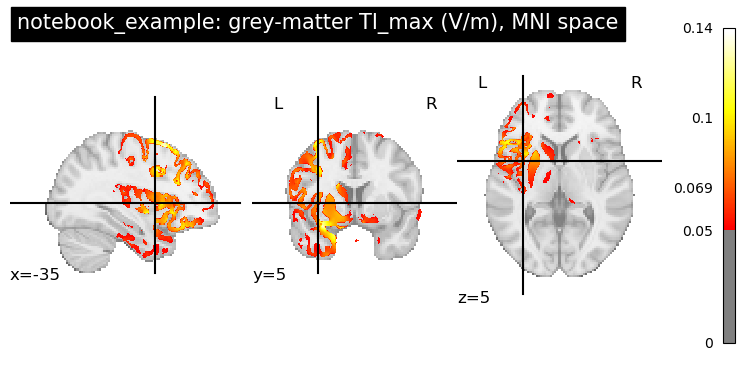

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nilearn import plotting

nifti_dir = sim_dir / "TI" / "niftis"
mni_img = next(nifti_dir.glob("grey_*MNI*TI_max.nii.gz"))

plotting.plot_stat_map(
    str(mni_img),
    cut_coords=(-35, 5, 5),
    threshold=0.05,
    cmap="hot",
    title=f"{montage.name}: grey-matter TI_max (V/m), MNI space",
)
plt.show()

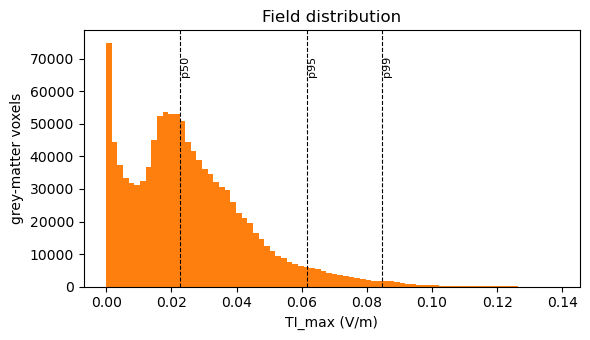

In [8]:
%matplotlib inline
gm = nib.load(str(mni_img)).get_fdata()
vals = gm[gm > 0]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(vals, bins=80, color="tab:orange")
for q in (50, 95, 99):
    ax.axvline(np.percentile(vals, q), color="k", ls="--", lw=0.8)
    ax.text(np.percentile(vals, q), ax.get_ylim()[1] * 0.9, f"p{q}", rotation=90, va="top", fontsize=8)
ax.set(xlabel="TI_max (V/m)", ylabel="grey-matter voxels", title="Field distribution")
plt.tight_layout()
plt.show()

## 7. Batch over subjects

Because all of this is plain Python, batching is just a loop. Dataset 000 has two head models
but we only simulated one, so the loop skips the other; on your project it iterates every subject with an `m2m_*` folder.

In [9]:
summary = []
for sid in pm.list_simnibs_subjects():
    if montage.name not in pm.list_simulations(sid):
        print(f"skipping sub-{sid}: no {montage.name} simulation yet (run_simulation would go here)")
        continue
    r = Analyzer(subject_id=sid, simulation=montage.name, space="voxel").analyze_sphere(
        center=(-35.0, 5.0, 5.0), radius=10.0, coordinate_space="MNI")
    summary.append({"subject": sid, "roi_mean": r.roi_mean, "roi_max": r.roi_max, "focality": r.roi_focality})
pd.DataFrame(summary).round(4)

skipping sub-101: no notebook_example simulation yet (run_simulation would go here)
Analyzer initialised: subject=ernie sim=notebook_example space=voxel tissue=GM field=TI_max


Saved results CSV: /mnt/000/derivatives/SimNIBS/sub-ernie/Simulations/notebook_example/Analyses/Voxel/sphere_x-35.00_y5.00_z5.00_r10.0_MNI/results.csv


Analysis complete for sphere_x-35.00_y5.00_z5.00_r10.0 (spherical)


skipping sub-MNI152: no notebook_example simulation yet (run_simulation would go here)


,subject,roi_mean,roi_max,focality
0,ernie,0.0763,0.1124,2.1232


## Where to go next

- [Scripting](../scripting/) — full API reference for `tit.sim`, `tit.opt`, `tit.analyzer`, `tit.stats`, `tit.pre`
- [Flex Search](../flex-search/) / [Ex Search](../ex-search/) — optimise electrode positions before simulating
- [AI Assistant](../ai-assistant/) — let a coding agent write these scripts with the toolbox's own docs at hand
- [API Reference](../../api/) — auto-generated from docstrings